In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import numpy as np


In [46]:
best=[]
best_name=[]
def problem_analysis(df):
    # Load S&P 500 data
    sp_data = pd.read_csv('SP500 Data.csv')

    # Load data
    oil_data = pd.read_csv(df+".csv")

    # Merge datasets on 'date' column
    merged_data = pd.merge(sp_data, oil_data, on='date', how='inner')


    # Drop rows with missing values
    if merged_data.isnull().values.any():
        print("Warning: Missing values found after merging. Removing those rows.")
        merged_data.dropna(inplace=True)

        # Define features and target variable
    X = merged_data[['SP500', ' value']]
    y = merged_data[' value'] #> merged_data[' value'].median()  # Binary target variable

    #imputer = SimpleImputer(strategy='median')
    #X = imputer.fit_transform(X)
    merged_data['date'] = pd.to_datetime(merged_data['date'])

    print(merged_data)

    correlation_value = merged_data['SP500'].corr(merged_data[' value'])
    print("Correlation between S&P 500 and "+ df +":", correlation_value)

    best.append(correlation_value)
    best_name.append(df)

    # Sort values by date
    merged_data.sort_values(by='date', inplace=True)

    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot 'SP500' on primary y-axis
    ax1.plot(merged_data['date'], merged_data['SP500'], color='blue', label='SP500')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('SP500', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Create secondary y-axis for 'value'
    ax2 = ax1.twinx()
    ax2.plot(merged_data['date'], merged_data[' value'], color='green', label='Crude Oil Price')
    ax2.set_ylabel(df, color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Fit linear regression models
    model_sp500 = LinearRegression().fit(merged_data.index.values.reshape(-1, 1), merged_data['SP500'])
    model_value = LinearRegression().fit(merged_data.index.values.reshape(-1, 1), merged_data[' value'])

    # Plot lines of best fit
    #ax1.plot(merged_data['date'], model_sp500.predict(merged_data.index.values.reshape(-1, 1)), color='red', linestyle='--', label='SP500 Line of Best Fit')
    #ax2.plot(merged_data['date'], model_value.predict(merged_data.index.values.reshape(-1, 1)), color='orange', linestyle='--', label='Value Line of Best Fit')

    # Add legend
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.title("Correlation between S&P 500 and "+ df +":")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    


           date        SP500   value
0    2011-05-09  1346.290039  100.32
1    2011-05-10  1357.160034  103.39
2    2011-05-11  1342.079956   97.88
3    2011-05-12  1348.650024   98.53
4    2011-05-13  1337.770020   99.21
...         ...          ...     ...
3256 2024-04-30  5035.689941   81.93
3257 2024-05-01  5018.390137   79.05
3258 2024-05-02  5064.200195   78.95
3259 2024-05-03  5127.790039   78.11
3260 2024-05-06  5180.740234   78.75

[3261 rows x 3 columns]
Correlation between S&P 500 and Crude oil price: -0.09451221149695047


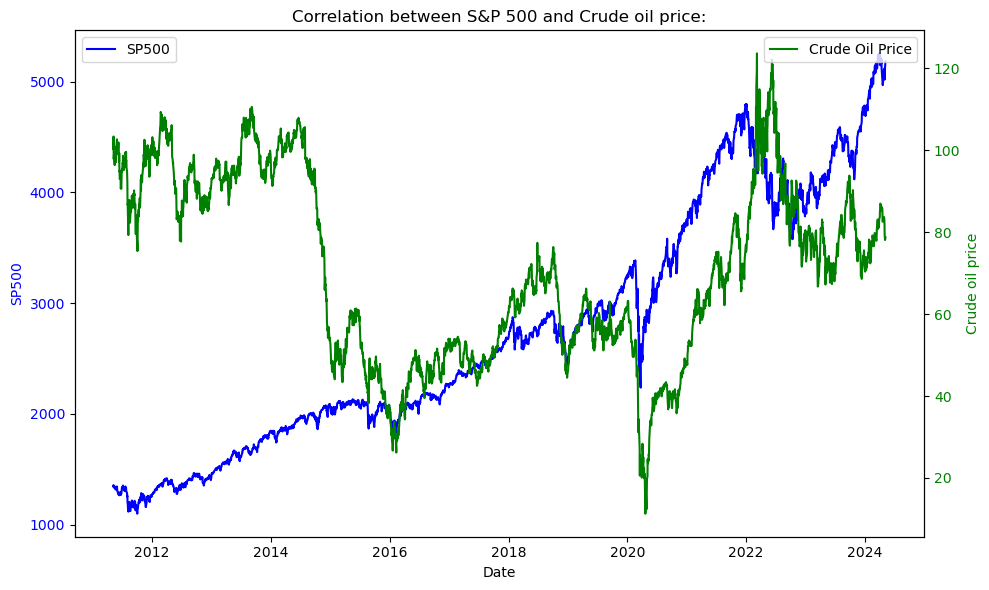

           date        SP500   value
0    2010-11-22  1197.839966    0.19
1    2010-11-23  1180.729980    0.20
2    2010-11-24  1198.349976    0.20
3    2010-11-26  1189.400024    0.20
4    2010-11-29  1187.760010    0.20
...         ...          ...     ...
3380 2024-04-30  5035.689941    5.33
3381 2024-05-01  5018.390137    5.33
3382 2024-05-02  5064.200195    5.33
3383 2024-05-03  5127.790039    5.33
3384 2024-05-06  5180.740234    5.33

[3385 rows x 3 columns]
Correlation between S&P 500 and Federal Interest rate: 0.6127552663600601


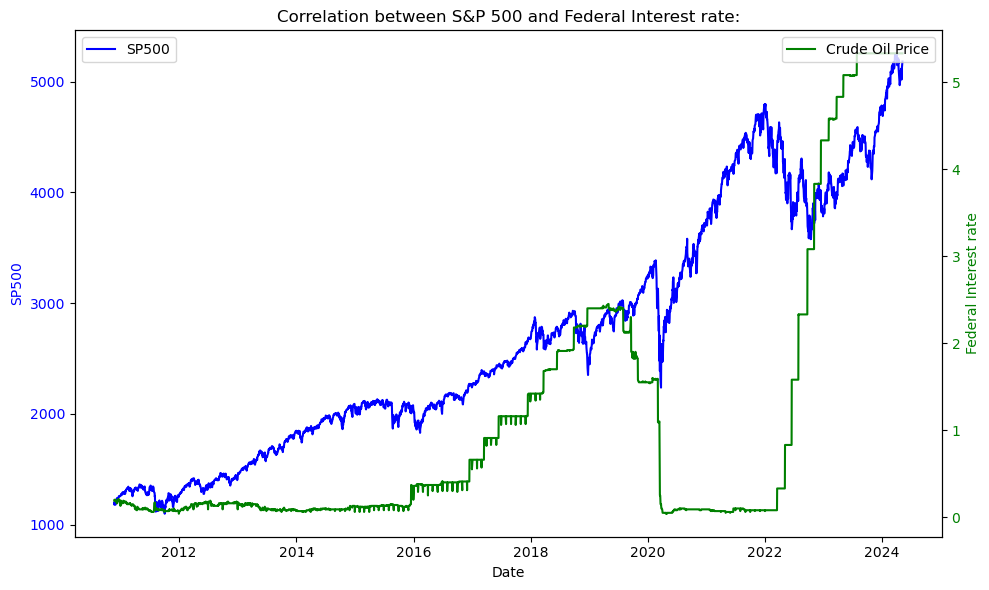

           date        SP500   value
0    2010-02-17  1099.510010    2.28
1    2010-02-18  1106.750000    2.31
2    2010-02-19  1109.170044    2.26
3    2010-02-22  1108.010010    2.25
4    2010-02-23  1094.599976    2.19
...         ...          ...     ...
3551 2024-05-03  5127.790039    2.35
3552 2024-05-06  5180.740234    2.35
3553 2024-05-07  5187.700195    2.32
3554 2024-05-08  5187.669922    2.31
3555 2024-05-09  5214.080078    2.32

[3556 rows x 3 columns]
Correlation between S&P 500 and Inflation rates: 0.23305319410165184


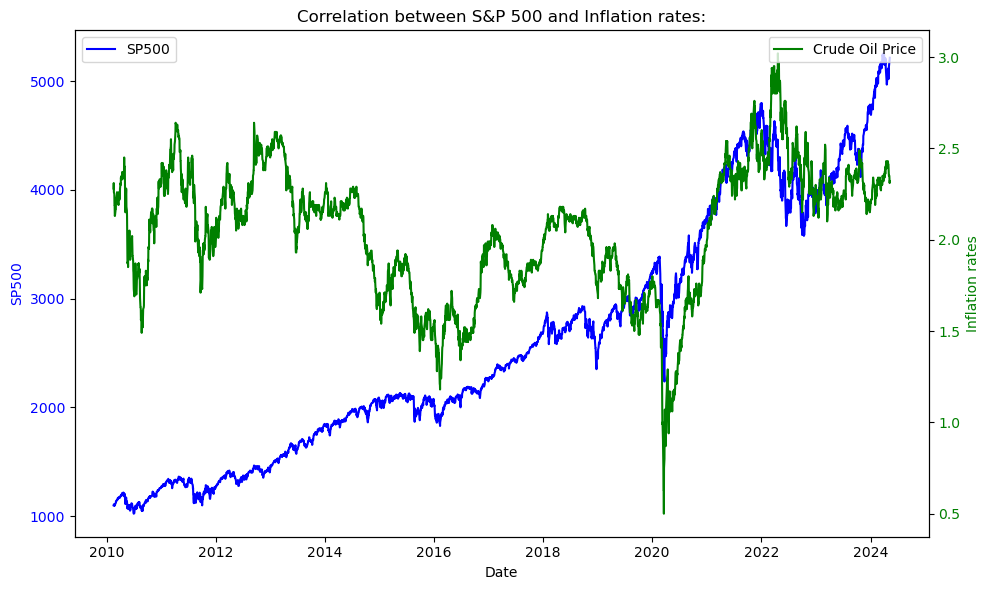

           date        SP500    value
0    2003-12-01  1070.119995  0.83577
1    2003-12-02  1066.619995  0.82720
2    2003-12-03  1064.729980  0.82488
3    2003-12-04  1069.719971  0.82775
4    2003-12-05  1061.500000  0.82055
...         ...          ...      ...
5141 2024-05-06  5180.740234  0.92953
5142 2024-05-07  5187.700195  0.92872
5143 2024-05-08  5187.669922  0.93019
5144 2024-05-09  5214.080078  0.93050
5145 2024-05-09  5214.080078  0.92700

[5117 rows x 3 columns]
Correlation between S&P 500 and US to Euro exchange rate: 0.6954356860271144


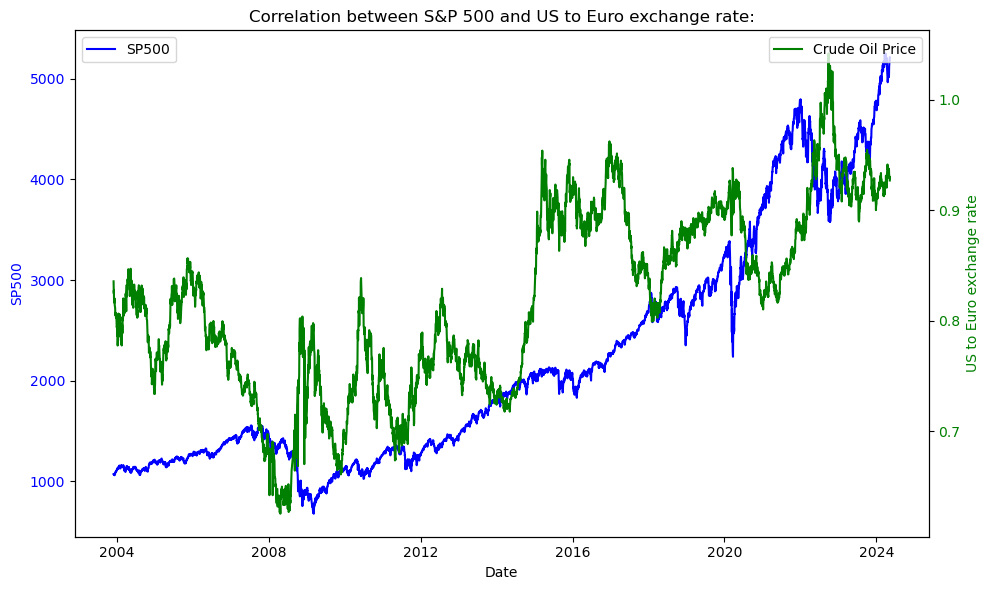

           date        SP500       value
0    1999-05-10  1340.300049    3.671875
1    1999-05-11  1355.609985    3.709375
2    1999-05-12  1364.000000    3.573438
3    1999-05-13  1367.560059    3.400000
4    1999-05-14  1337.800049    3.309375
...         ...          ...         ...
6287 2024-05-03  5127.790039  186.210007
6288 2024-05-06  5180.740234  188.699997
6289 2024-05-07  5187.700195  188.759995
6290 2024-05-08  5187.669922  188.000000
6291 2024-05-09  5214.080078  189.500000

[6292 rows x 3 columns]
Correlation between S&P 500 and Amazon Stock: 0.9588905152872744


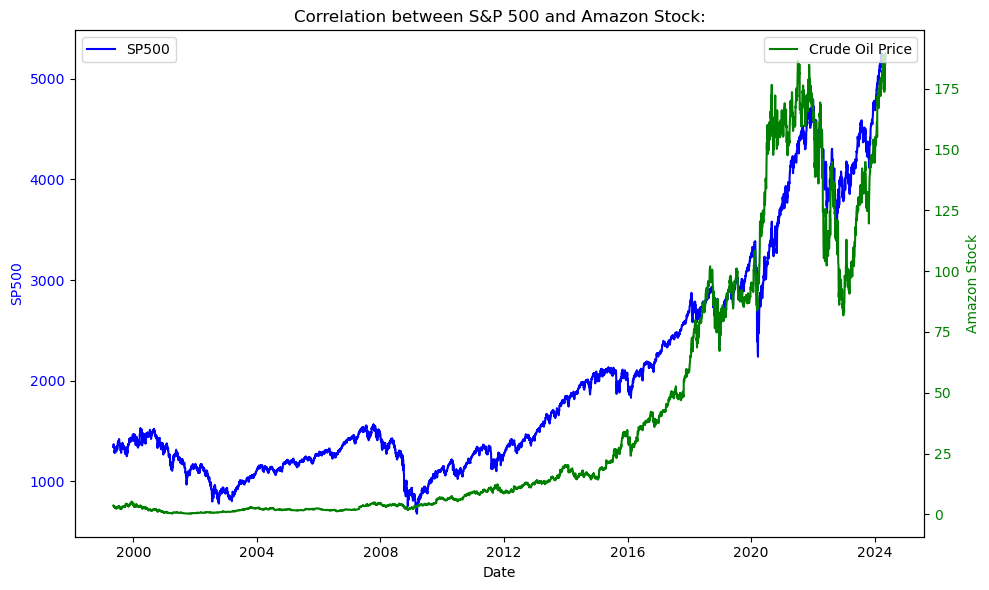

           date        SP500       value
0    1999-05-10  1340.300049    0.404018
1    1999-05-11  1355.609985    0.399554
2    1999-05-12  1364.000000    0.415179
3    1999-05-13  1367.560059    0.412388
4    1999-05-14  1337.800049    0.396205
...         ...          ...         ...
6287 2024-05-03  5127.790039  183.380005
6288 2024-05-06  5180.740234  181.710007
6289 2024-05-07  5187.700195  182.399994
6290 2024-05-08  5187.669922  182.740005
6291 2024-05-09  5214.080078  184.570007

[6292 rows x 3 columns]
Correlation between S&P 500 and Apple Stock: 0.9619272571194688


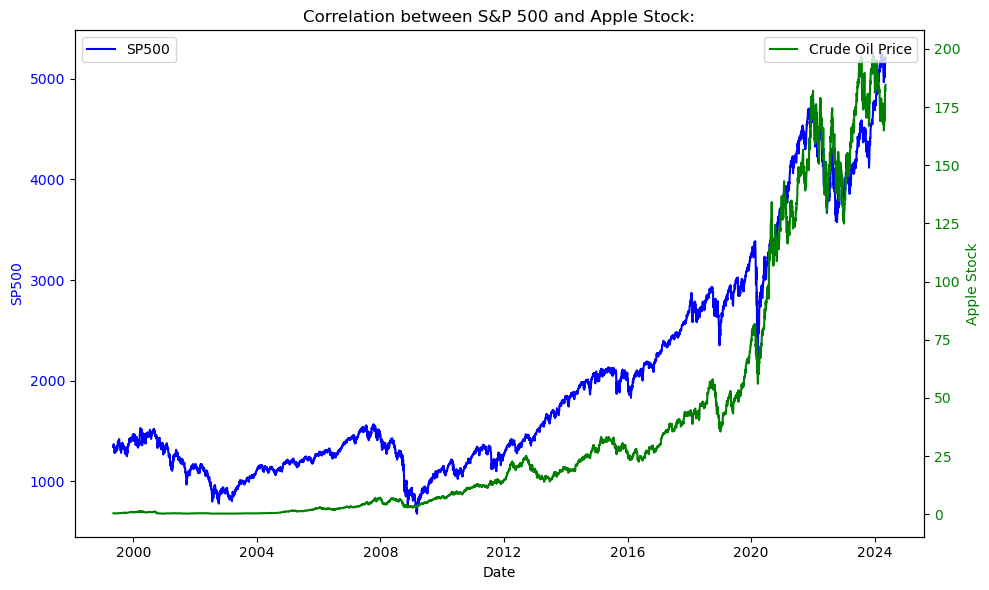

           date        SP500       value
0    1999-05-10  1340.300049   39.843750
1    1999-05-11  1355.609985   39.937500
2    1999-05-12  1364.000000   40.250000
3    1999-05-13  1367.560059   39.562500
4    1999-05-14  1337.800049   38.437500
...         ...          ...         ...
6287 2024-05-03  5127.790039  406.660004
6288 2024-05-06  5180.740234  413.540009
6289 2024-05-07  5187.700195  409.339996
6290 2024-05-08  5187.669922  410.540009
6291 2024-05-09  5214.080078  412.320007

[6292 rows x 3 columns]
Correlation between S&P 500 and Mircosoft Stock: 0.9577163473491773


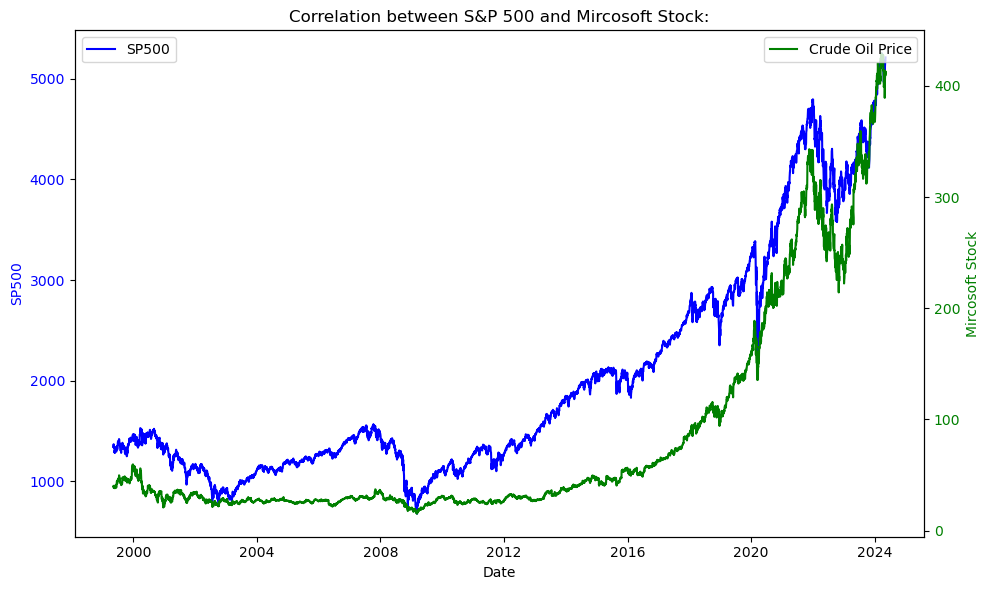

           date        SP500      value
0    1999-05-10  1340.300049  18.875000
1    1999-05-11  1355.609985  19.312500
2    1999-05-12  1364.000000  18.937500
3    1999-05-13  1367.560059  19.500000
4    1999-05-14  1337.800049  19.250000
...         ...          ...        ...
6287 2024-05-03  5127.790039  16.459999
6288 2024-05-06  5180.740234  16.670000
6289 2024-05-07  5187.700195  16.740000
6290 2024-05-08  5187.669922  16.719999
6291 2024-05-09  5214.080078  17.030001

[6292 rows x 3 columns]
Correlation between S&P 500 and Gold value: -0.36287200331015523


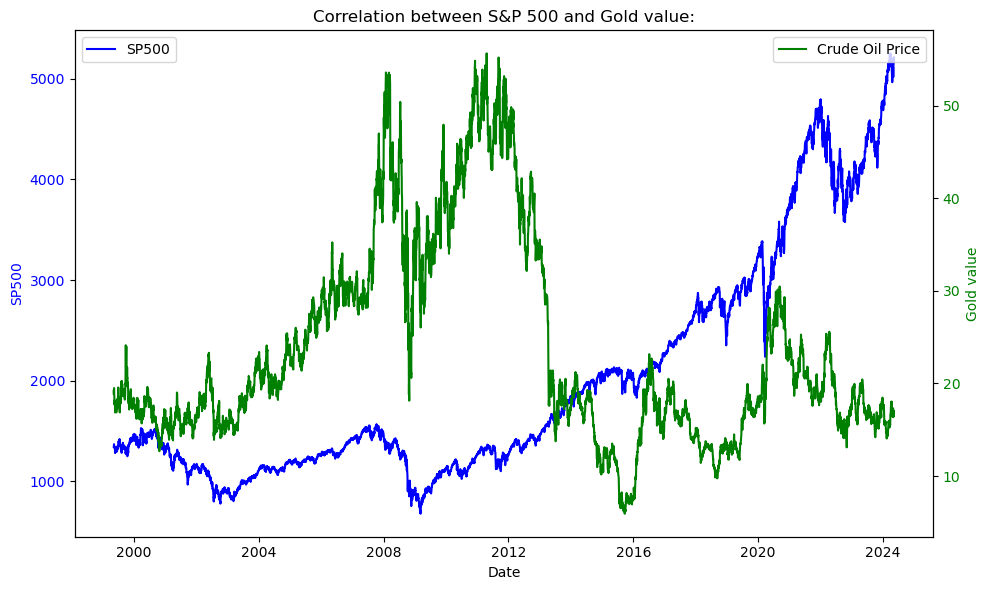

           date        SP500         value
0    1999-05-10  1340.300049   2526.389893
1    1999-05-11  1355.609985   2566.679932
2    1999-05-12  1364.000000   2606.540039
3    1999-05-13  1367.560059   2582.000000
4    1999-05-14  1337.800049   2527.860107
...         ...          ...           ...
6287 2024-05-03  5127.790039  16156.330078
6288 2024-05-06  5180.740234  16349.250000
6289 2024-05-07  5187.700195  16332.559570
6290 2024-05-08  5187.669922  16302.759766
6291 2024-05-09  5214.080078  16346.259766

[6292 rows x 3 columns]
Correlation between S&P 500 and Nasdq stock: 0.9921511739557844


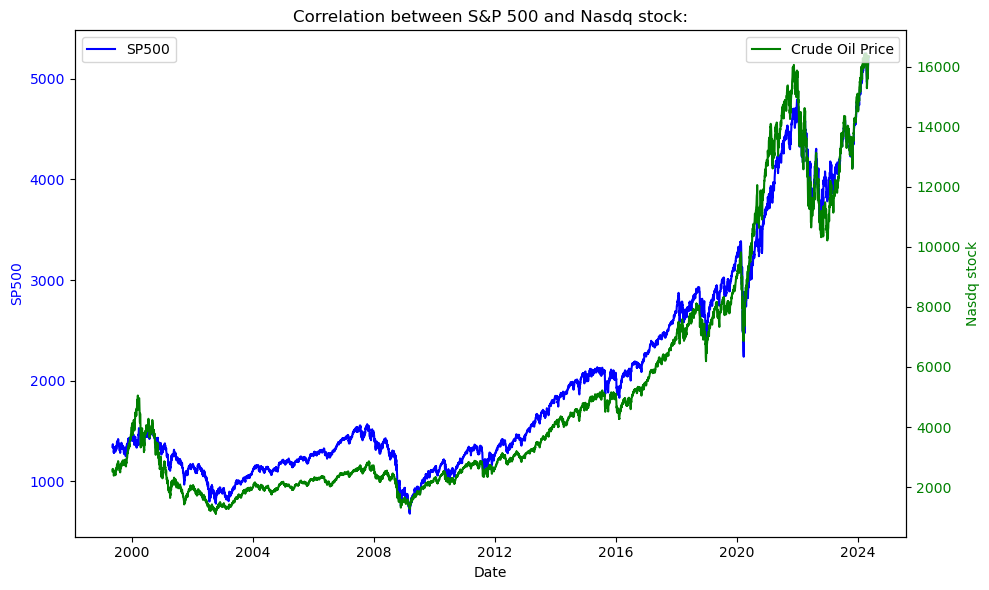

Results:
   Correlation                      Name
8     0.992151               Nasdq stock
5     0.961927               Apple Stock
4     0.958891              Amazon Stock
6     0.957716           Mircosoft Stock
3     0.695436  US to Euro exchange rate
1     0.612755     Federal Interest rate
7     0.362872                Gold value
2     0.233053           Inflation rates
0     0.094512           Crude oil price


In [47]:
#Oil price
problem_analysis('Crude oil price')

#Federal Interest rates
problem_analysis('Federal Interest rate')

#Inflation rates
problem_analysis('Inflation rates')

#US to euro currency equivilent
problem_analysis('US to Euro exchange rate')

#amazon stock
problem_analysis('Amazon Stock')

#apple stock
problem_analysis('Apple Stock')

#microsoft stock
problem_analysis('Mircosoft Stock')

#gold Price
problem_analysis('Gold value')

#Nasdq stock
problem_analysis('Nasdq stock')

print("Results:")
sf = pd.DataFrame({'Correlation':best,'Name': best_name})
sf['Correlation'] = sf['Correlation'].abs()

sf= sf.sort_values(by='Correlation',  ascending=False)

print(sf)